# Step 1: Build Hourly Demand Time Series (NYC TLC Yellow Taxi)

Goal: Convert trip-level parquet files into an hourly demand time series:
`timestamp, demand` where demand = number of pickups per hour (2024 Jan–Mar).

## Data Source
NYC TLC Trip Record Data (Yellow Taxi), 2024 Jan–Mar (parquet files).

## Method
1) Read pickup datetime
2) Filter to valid month range (removes bad timestamp outliers)
3) Floor timestamps to hourly buckets
4) Count trips per hour
5) Fill missing hours with 0
6) Save as `demand.csv`

In [19]:
#!pip install pandas pyarrow

In [27]:
#!pip install pandas numpy matplotlib scikit-learn

In [28]:
#!pip install statsmodels

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# Step :1 

### Converting paraquet files into demand.csv

In [12]:
import pandas as pd
import glob, os

# 1) Config
DATA_DIR = r"C:\Users\chava\Downloads\Marketplace Demand Forecasting + Supply Simulator"
pattern = os.path.join(DATA_DIR, "yellow_tripdata_2024-*.parquet")
files = sorted(glob.glob(pattern))
col = "tpep_pickup_datetime"

print("Files:", *files, sep="\n")


Files:
C:\Users\chava\Downloads\Marketplace Demand Forecasting + Supply Simulator\yellow_tripdata_2024-01.parquet
C:\Users\chava\Downloads\Marketplace Demand Forecasting + Supply Simulator\yellow_tripdata_2024-02.parquet
C:\Users\chava\Downloads\Marketplace Demand Forecasting + Supply Simulator\yellow_tripdata_2024-03.parquet


In [13]:
# 2) check on first file
tmp = pd.read_parquet(files[0], columns=[col])
tmp[col] = pd.to_datetime(tmp[col], errors="coerce")
print("\nRaw min/max (first file):", tmp[col].min(), tmp[col].max())


Raw min/max (first file): 2002-12-31 22:59:39 2024-02-01 00:01:15


### Converting to hourly demand and filling out the missing hours

In [15]:
# 3) Build hourly demand
all_hours = []

for f in files:
    df = pd.read_parquet(f, columns=[col])
    df[col] = pd.to_datetime(df[col], errors="coerce")

    # infer month from filename
    ym = os.path.basename(f).replace("yellow_tripdata_", "").replace(".parquet", "")
    start = pd.to_datetime(f"{ym}-01")
    end = start + pd.offsets.MonthEnd(1) + pd.Timedelta(hours=23, minutes=59, seconds=59)

    # filter bad timestamps
    df = df[(df[col] >= start) & (df[col] <= end)]

    df["timestamp"] = df[col].dt.floor("h")
    hourly = df.groupby("timestamp").size().reset_index(name="demand")
    all_hours.append(hourly)

demand_df = pd.concat(all_hours, ignore_index=True)
demand_df = demand_df.groupby("timestamp", as_index=False)["demand"].sum()
demand_df = demand_df.sort_values("timestamp")

# 4) Fill missing hours
full_range = pd.date_range(demand_df["timestamp"].min(), demand_df["timestamp"].max(), freq="h")
demand_df = (demand_df.set_index("timestamp")
             .reindex(full_range, fill_value=0)
             .rename_axis("timestamp")
             .reset_index())

# 5) Save
out_path = os.path.join(DATA_DIR, "demand.csv")
demand_df.to_csv(out_path, index=False)

print("\nSaved:", out_path)
print("Final Min/Max:", demand_df["timestamp"].min(), demand_df["timestamp"].max())
print("Shape:", demand_df.shape)
print(demand_df["demand"].describe())


Saved: C:\Users\chava\Downloads\Marketplace Demand Forecasting + Supply Simulator\demand.csv
Final Min/Max: 2024-01-01 00:00:00 2024-03-31 23:00:00
Shape: (2184, 2)
count     2184.000000
mean      4374.872711
std       2535.304655
min          0.000000
25%       1875.000000
50%       5020.000000
75%       6247.000000
max      11671.000000
Name: demand, dtype: float64


In [16]:
demand_df.shape

(2184, 2)

In [17]:
demand_df["demand"].describe()

count     2184.000000
mean      4374.872711
std       2535.304655
min          0.000000
25%       1875.000000
50%       5020.000000
75%       6247.000000
max      11671.000000
Name: demand, dtype: float64

In [18]:
import pandas as pd
df0 = pd.read_parquet(files[0])
df0.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee'],
      dtype='str')

# Step:2 : EDA + Forecasting

### Load demand.csv + quick sanity plots

In [20]:
DATA_DIR = r"C:\Users\chava\Downloads\Marketplace Demand Forecasting + Supply Simulator"
df = pd.read_csv(f"{DATA_DIR}/demand.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

df.head(), df.tail(), df.shape

(            timestamp  demand
 0 2024-01-01 00:00:00    6596
 1 2024-01-01 01:00:00    7355
 2 2024-01-01 02:00:00    6220
 3 2024-01-01 03:00:00    4936
 4 2024-01-01 04:00:00    3188,
                timestamp  demand
 2179 2024-03-31 19:00:00    5410
 2180 2024-03-31 20:00:00    5698
 2181 2024-03-31 21:00:00    5070
 2182 2024-03-31 22:00:00    3720
 2183 2024-03-31 23:00:00    2231,
 (2184, 2))

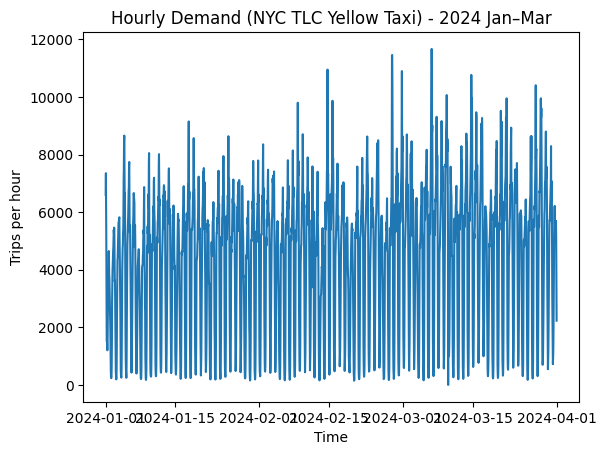

In [21]:
plt.figure()
plt.plot(df["timestamp"], df["demand"])
plt.title("Hourly Demand (NYC TLC Yellow Taxi) - 2024 Jan–Mar")
plt.xlabel("Time")
plt.ylabel("Trips per hour")
plt.show()

### Train/Test split (time-based, not random)
#### Last two weeks as a test

In [32]:
test_hours = 24 * 14
train = df.iloc[:-test_hours].copy()
test  = df.iloc[-test_hours:].copy()

train.shape, test.shape

((1848, 2), (336, 2))

### Baseline model (Seasonal Naive)

#### For hourly data, daily seasonality = 24.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [44]:
# --- Baseline: Seasonal Naive (daily seasonality for hourly data) ---
season = 24

y_train = train["demand"].values
y_test  = test["demand"].values

baseline_pred = np.tile(
    y_train[-season:], int(np.ceil(len(y_test) / season))
)[:len(y_test)]

def wape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    return np.sum(np.abs(y_true - y_pred)) / max(denom, 1e-6)

def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred))
    return np.mean(2 * np.abs(y_pred - y_true) / np.maximum(denom, 1e-6))

baseline_mae  = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_wape = wape(y_test, baseline_pred)
baseline_smape = smape(y_test, baseline_pred)

print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline WAPE:", baseline_wape)
print("Baseline sMAPE:", baseline_smape)

Baseline MAE : 1587.970238095238
Baseline RMSE: 2236.0865381179638
Baseline WAPE: 0.3359408153628207
Baseline sMAPE: 0.4424957804368221


# Random Forest

In [45]:
# --- Random Forest metrics (requires rf_pred + y_test) ---
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_wape = wape(y_test, rf_pred)
rf_smape = smape(y_test, rf_pred)

print("RF MAE :", rf_mae)
print("RF RMSE:", rf_rmse)
print("RF WAPE:", rf_wape)
print("RF sMAPE:", rf_smape)

RF MAE : 299.25804429767476
RF RMSE: 446.913756704978
RF WAPE: 0.06330911562034863
RF sMAPE: 0.07794818001964637


###### Random Forest is a massive improvement:

MAE improved from 1588 → 299 (about 5.3× better)

WAPE improved from 33.6% → 6.3% (about 5.3× better)

RMSE improved from 2236 → 447 (about 5× better)

That’s strong enough to justify using RF forecasts for your simulator.

In [46]:
len(y_test), len(rf_pred)

(336, 336)

### Plot actual vs baseline:

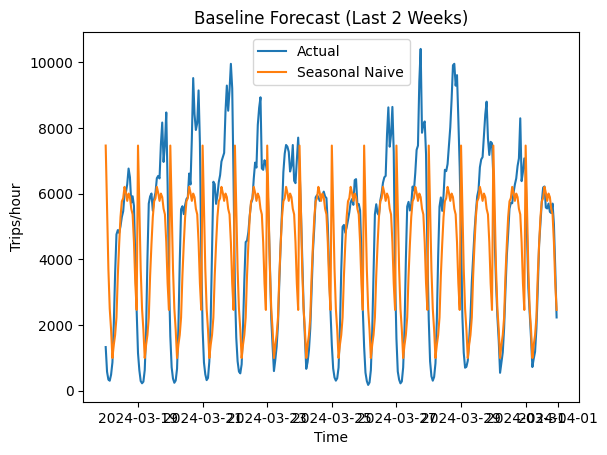

In [35]:
plt.figure()
plt.plot(test["timestamp"], y_test, label="Actual")
plt.plot(test["timestamp"], baseline_pred, label="Seasonal Naive")
plt.title("Baseline Forecast (Last 2 Weeks)")
plt.xlabel("Time")
plt.ylabel("Trips/hour")
plt.legend()
plt.show()

### A real model (RandomForest with time features)

We’ll build simple features: hour, dayofweek, lags.

In [36]:
def make_features(data):
    d = data.copy()
    ts = pd.to_datetime(d["timestamp"])
    d["hour"] = ts.dt.hour
    d["dow"] = ts.dt.dayofweek
    d["lag_1"] = d["demand"].shift(1)
    d["lag_24"] = d["demand"].shift(24)
    d["lag_168"] = d["demand"].shift(168)  # 7 days
    return d.dropna()

feat = make_features(df)
train_f = feat.iloc[:-test_hours].copy()
test_f  = feat.iloc[-test_hours:].copy()

X_train = train_f[["hour","dow","lag_1","lag_24","lag_168"]]
y_train = train_f["demand"]
X_test  = test_f[["hour","dow","lag_1","lag_24","lag_168"]]
y_test  = test_f["demand"]


#train and predict

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=3
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [41]:
mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
mape_rf = np.mean(np.abs((y_test - rf_pred) / np.maximum(y_test, 1)))

(mae_rf, rmse_rf, mape_rf)



(299.25804429767476,
 np.float64(446.913756704978),
 np.float64(0.08245144858939042))

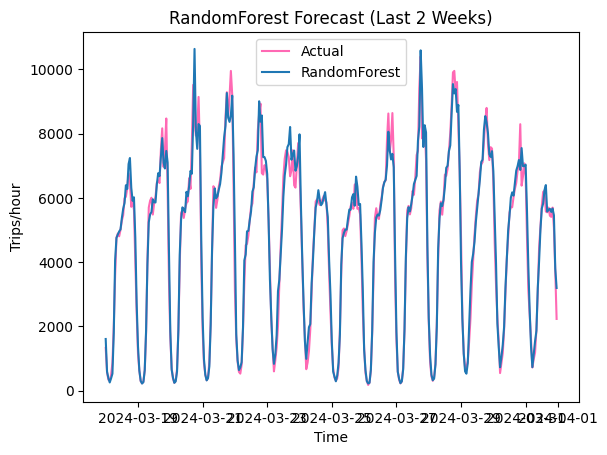

In [42]:
plt.figure()
plt.plot(test_f["timestamp"], y_test.values, label="Actual" ,color = "hotpink")
plt.plot(test_f["timestamp"], rf_pred, label="RandomForest")
plt.title("RandomForest Forecast (Last 2 Weeks)")
plt.xlabel("Time")
plt.ylabel("Trips/hour" ,color= 'Black')
plt.legend()
plt.show()

# Step :3 :Marketplace Simulator

### 3A :Prepare the forecast series

In [63]:
sim_input = pd.DataFrame({
    "timestamp": test_f["timestamp"].values,
    "demand_forecast": np.maximum(rf_pred, 0)  # no negative demand
})
sim_input.head()

,timestamp,demand_forecast
0,2024-03-18 00:00:00,1606.298041
1,2024-03-18 01:00:00,586.586161
2,2024-03-18 02:00:00,386.994743
3,2024-03-18 03:00:00,252.766106
4,2024-03-18 04:00:00,380.131116


In [64]:
test_f["demand"].head()

1848    1329
1849     577
1850     338
1851     304
1852     489
Name: demand, dtype: int64

In [65]:
test_f["demand"].describe()

count      336.000000
mean      4726.934524
std       2671.289736
min        176.000000
25%       2092.500000
50%       5533.500000
75%       6639.000000
max      10408.000000
Name: demand, dtype: float64

In [66]:
rf_pred.min(), rf_pred.max(), rf_pred.mean()

(np.float64(219.35700673400672),
 np.float64(10639.34346127021),
 np.float64(4804.186841274755))

#### What your outputs mean

Actual first few hours: 1329, 577, 338, 304, 489

Predicted first few hours: ~1606, 586, 387, 253, 380
That’s close enough. Night hours are low; daytime spikes are high.

Test period stats:

Actual mean ≈ 4727

Pred mean ≈ 4804

Actual max ≈ 10408

Pred max ≈ 10639
So scale is consistent.

### Step 3B — Build simulator input (include actual + forecast)

In [67]:
import pandas as pd
import numpy as np

sim_input = pd.DataFrame({
    "timestamp": test_f["timestamp"].values,
    "demand_actual": test_f["demand"].values,
    "demand_forecast": np.maximum(rf_pred, 0)
})

sim_input.head()

,timestamp,demand_actual,demand_forecast
0,2024-03-18 00:00:00,1329,1606.298041
1,2024-03-18 01:00:00,577,586.586161
2,2024-03-18 02:00:00,338,386.994743
3,2024-03-18 03:00:00,304,252.766106
4,2024-03-18 04:00:00,489,380.131116


# Step 3C — Marketplace simulator (simple queue model)

In [68]:
import pandas as pd

def simulate_marketplace(
    sim_df,
    demand_col="demand_forecast",
    supply_per_hour=5000,
    max_queue=20000,
    cancel_threshold=10000,
    base_fare=12.0,
    surge_cap=2.0
):
    """
    Queue-based marketplace simulator (discrete-time, 1 step = 1 hour).

    Interpretation:
    - arrivals: demand arriving each hour (forecast or actual)
    - supply_per_hour: max number of orders the system can fulfill per hour (capacity)
    - queue: unmet demand carried over to next hour (backlog)

    Outputs (per hour):
    - served: fulfilled orders
    - canceled: dropped orders (overflow or abandonment)
    - queue_end: backlog after service + cancellations
    - queue_delay_minutes_proxy: backlog expressed as minutes of work remaining
      (this is NOT a literal customer ETA; it's a congestion/backlog proxy)
    - surge_mult: pricing multiplier driven by congestion
    - revenue: served * base_fare * surge_mult (simulated)
    """
    queue = 0
    rows = []

    for ts, arrivals in zip(sim_df["timestamp"], sim_df[demand_col]):
        # 1) Convert arrivals to a clean non-negative integer
        arrivals = int(round(arrivals))
        arrivals = max(arrivals, 0)

        # 2) Add arrivals to the backlog queue
        queue += arrivals

        # 3) Hard overflow cancellations:
        # If queue exceeds system limit (max_queue), excess demand is canceled immediately.
        canceled = 0
        if queue > max_queue:
            canceled += (queue - max_queue)
            queue = max_queue

        # 4) Fulfillment (service):
        # The system can serve up to `supply_per_hour` orders this hour.
        served = min(queue, supply_per_hour)
        queue -= served

        # 5) Abandonment cancellations (behavioral):
        # If backlog is high, some customers drop off (simple rule: 2% of queue).
        if queue > cancel_threshold:
            extra_cancel = int(0.02 * queue)
            queue -= extra_cancel
            canceled += extra_cancel

        # 6) Surge multiplier:
        # Congestion-based surge (queue relative to threshold), capped at surge_cap.
        if queue <= cancel_threshold:
            surge = 1.0
        else:
            surge = min(surge_cap, queue / cancel_threshold)

        # 7) Simulated revenue:
        # Note: This is NOT real TLC revenue; it's a proxy tied to served volume & surge.
        revenue = served * base_fare * surge

        # 8) Congestion proxy (minutes of backlog remaining):
        # backlog hours = queue / capacity; convert hours → minutes.
        # This is NOT a literal ETA, just "how much work is waiting."
        queue_delay_minutes_proxy = 60 * (queue / max(supply_per_hour, 1))

        # 9) Store hourly results
        rows.append({
            "timestamp": ts,
            "arrivals": arrivals,
            "served": served,
            "canceled": canceled,
            "queue_end": queue,
            "queue_delay_minutes_proxy": queue_delay_minutes_proxy,
            "surge_mult": surge,
            "revenue": revenue
        })

    return pd.DataFrame(rows)

# Step 3D — Run 1 simulation + summarize

In [69]:
sim_out = simulate_marketplace(sim_input, demand_col="demand_forecast", supply_per_hour=5000)
# supply_per_hour = fulfillment capacity per hour (orders completed per hour)

total_demand = sim_out["arrivals"].sum()
served = sim_out["served"].sum()
canceled = sim_out["canceled"].sum()

print("Total demand:", total_demand)
print("Served:", served)
print("Canceled:", canceled)
print("Cancel rate:", canceled / total_demand)
print("Avg queue delay proxy (minutes):", sim_out["queue_delay_minutes_proxy"].mean())
print("Total revenue (simulated):", sim_out["revenue"].sum())
print("Cancel rate:", canceled / max(total_demand, 1))

Total demand: 1614202
Served: 1452892
Canceled: 156597
Cancel rate: 0.09701202203937302
Avg queue delay proxy (minutes): 69.95064285714287
Total revenue (simulated): 19578666.0
Cancel rate: 0.09701202203937302


# actual value comes from policy comparison

In [70]:
policies = [
    ("Base", 5000),
    ("-10% capacity", 4500),
    ("+10% capacity", 5500),
    ("+20% capacity", 6000)
]

summary = []
for name, cap in policies:
    out = simulate_marketplace(sim_input, demand_col="demand_forecast", supply_per_hour=cap)
    total_demand = out["arrivals"].sum()
    canceled = out["canceled"].sum()

    summary.append({
        "policy": name,
        "capacity_per_hour": cap,
        "cancel_rate": canceled / max(total_demand, 1),
        "avg_queue_delay_mins": out["queue_delay_minutes_proxy"].mean(),
        "total_revenue": out["revenue"].sum()
    })

policy_table = pd.DataFrame(summary).sort_values(
    ["cancel_rate", "avg_queue_delay_mins", "total_revenue"],
    ascending=[True, True, False]
)

policy_table

,policy,capacity_per_hour,cancel_rate,avg_queue_delay_mins,total_revenue
3,+20% capacity,6000,0.025054,30.112024,19787548.8
2,+10% capacity,5500,0.053706,47.205974,19880289.6
0,Base,5000,0.097012,69.950643,19578666.0
1,-10% capacity,4500,0.146666,99.549683,19363735.8


#### Capacity impact

-10% capacity (4500): cancel rate jumps to 14.67%, ETA 1.66h → worse across the board.

Base (5000): cancel 9.70%, ETA 1.17h

+10% capacity (5500): cancel drops to 5.37%, ETA 0.79h

+20% capacity (6000): cancel drops to 2.51%, ETA 0.50h

So increasing capacity clearly improves customer experience.

In [71]:
policy_table

,policy,capacity_per_hour,cancel_rate,avg_queue_delay_mins,total_revenue
3,+20% capacity,6000,0.025054,30.112024,19787548.8
2,+10% capacity,5500,0.053706,47.205974,19880289.6
0,Base,5000,0.097012,69.950643,19578666.0
1,-10% capacity,4500,0.146666,99.549683,19363735.8


In [73]:
# =========================
# Step 3F: Profit Analysis
# =========================

# Business assumption:
# Increasing capacity costs money (paying couriers, incentives, ops overhead, etc.)
# We model cost as: cost_per_order_capacity * capacity_per_hour * number_of_hours

hours = len(sim_input)  # number of simulated hours (same as your test horizon)

# CHANGE THIS number to test scenarios:
# Example: $1.50 per unit of hourly capacity per hour (you can try 0.5, 1, 2, 3, etc.)
cost_per_capacity_unit_per_hour = 1.50

pt = policy_table.copy()

# Total capacity cost over the simulation horizon
pt["capacity_cost"] = pt["capacity_per_hour"] * hours * cost_per_capacity_unit_per_hour

# Profit = simulated revenue - capacity cost
pt["profit"] = pt["total_revenue"] - pt["capacity_cost"]

# Show key columns sorted by profit (highest first)
profit_table = pt[[
    "policy",
    "capacity_per_hour",
    "cancel_rate",
    "avg_queue_delay_mins",
    "total_revenue",
    "capacity_cost",
    "profit"
]].sort_values("profit", ascending=False)

profit_table

,policy,capacity_per_hour,cancel_rate,avg_queue_delay_mins,total_revenue,capacity_cost,profit
2,+10% capacity,5500,0.053706,47.205974,19880289.6,2772000.0,17108289.6
1,-10% capacity,4500,0.146666,99.549683,19363735.8,2268000.0,17095735.8
0,Base,5000,0.097012,69.950643,19578666.0,2520000.0,17058666.0
3,+20% capacity,6000,0.025054,30.112024,19787548.8,3024000.0,16763548.8


In [74]:
# Find the cost per capacity unit where the best policy changes
import numpy as np

def best_policy_for_cost(c):
    pt = policy_table.copy()
    pt["capacity_cost"] = pt["capacity_per_hour"] * hours * c
    pt["profit"] = pt["total_revenue"] - pt["capacity_cost"]
    best = pt.sort_values("profit", ascending=False).iloc[0]
    return best["policy"]

for c in [0.25, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0]:
    print(c, "->", best_policy_for_cost(c))

0.25 -> +10% capacity
0.5 -> +10% capacity
1.0 -> +10% capacity
1.5 -> +10% capacity
2.0 -> -10% capacity
3.0 -> -10% capacity
4.0 -> -10% capacity


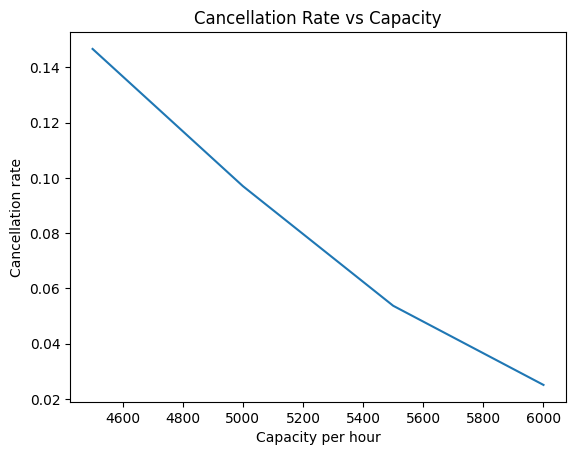

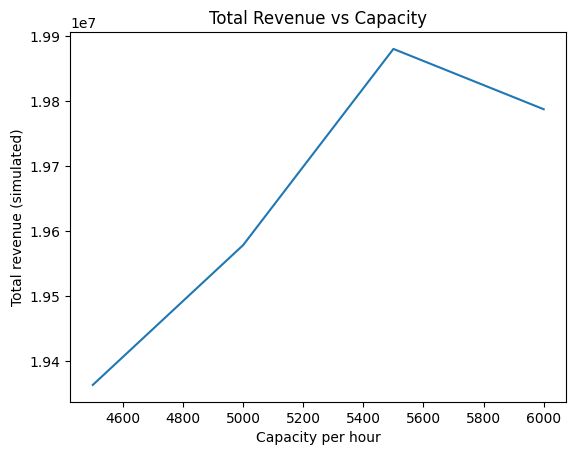

In [75]:
import matplotlib.pyplot as plt

# Make sure policy_table exists
pt = policy_table.sort_values("capacity_per_hour")

plt.figure()
plt.plot(pt["capacity_per_hour"], pt["cancel_rate"])
plt.title("Cancellation Rate vs Capacity")
plt.xlabel("Capacity per hour")
plt.ylabel("Cancellation rate")
plt.show()

plt.figure()
plt.plot(pt["capacity_per_hour"], pt["total_revenue"])
plt.title("Total Revenue vs Capacity")
plt.xlabel("Capacity per hour")
plt.ylabel("Total revenue (simulated)")
plt.show()

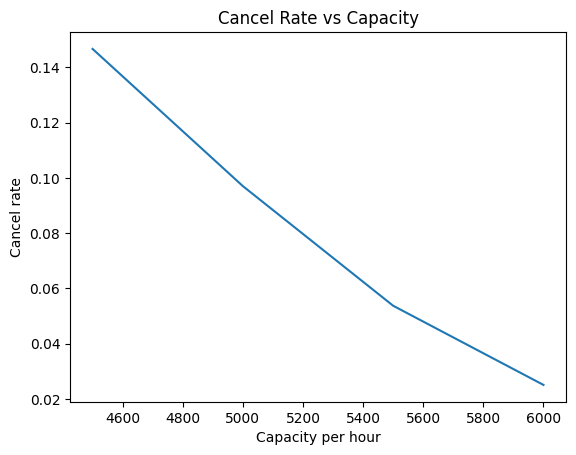

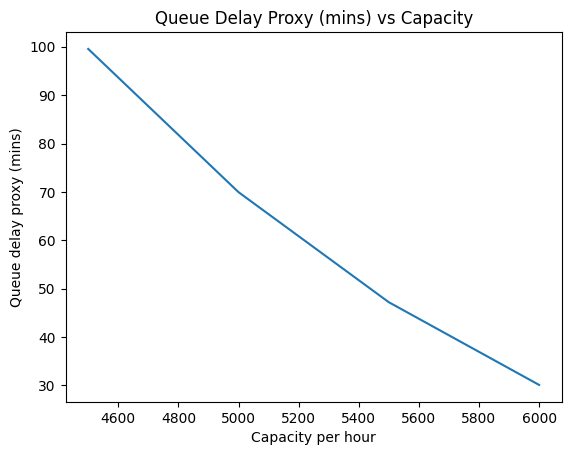

In [76]:
pt = policy_table.sort_values("capacity_per_hour")

import matplotlib.pyplot as plt

plt.figure()
plt.plot(pt["capacity_per_hour"], pt["cancel_rate"])
plt.title("Cancel Rate vs Capacity")
plt.xlabel("Capacity per hour")
plt.ylabel("Cancel rate")
plt.show()

plt.figure()
plt.plot(pt["capacity_per_hour"], pt["avg_queue_delay_mins"])
plt.title("Queue Delay Proxy (mins) vs Capacity")
plt.xlabel("Capacity per hour")
plt.ylabel("Queue delay proxy (mins)")
plt.show()

# Step 4: Add cancellation penalty and compute “adjusted profit”

In [77]:
import pandas as pd

# ---------- SETTINGS (you can change these later) ----------
cost_per_capacity_unit_per_hour = 1.50  # cost for 1 unit of hourly capacity for 1 hour
cancel_penalty_per_order = 8.0          # assumed cost per canceled order (refund/credits/support)
# ----------------------------------------------------------

hours = len(sim_input)  # number of hours simulated

policies = [
    ("Base", 5000),
    ("-10% capacity", 4500),
    ("+10% capacity", 5500),
    ("+20% capacity", 6000)
]

summary = []
for name, cap in policies:
    out = simulate_marketplace(sim_input, demand_col="demand_forecast", supply_per_hour=cap)

    total_demand = out["arrivals"].sum()
    canceled = out["canceled"].sum()

    total_revenue = out["revenue"].sum()
    capacity_cost = cap * hours * cost_per_capacity_unit_per_hour
    cancel_cost = canceled * cancel_penalty_per_order

    profit_adj = total_revenue - capacity_cost - cancel_cost

    summary.append({
        "policy": name,
        "capacity_per_hour": cap,
        "cancel_rate": canceled / max(total_demand, 1),
        "avg_queue_delay_mins": out["queue_delay_minutes_proxy"].mean(),
        "total_revenue": total_revenue,
        "capacity_cost": capacity_cost,
        "cancel_cost": cancel_cost,
        "profit_adj": profit_adj
    })

adj_table = pd.DataFrame(summary).sort_values("profit_adj", ascending=False)
adj_table

,policy,capacity_per_hour,cancel_rate,avg_queue_delay_mins,total_revenue,capacity_cost,cancel_cost,profit_adj
3,+20% capacity,6000,0.025054,30.112024,19787548.8,3024000.0,323544.0,16440004.8
2,+10% capacity,5500,0.053706,47.205974,19880289.6,2772000.0,693544.0,16414745.6
0,Base,5000,0.097012,69.950643,19578666.0,2520000.0,1252776.0,15805890.0
1,-10% capacity,4500,0.146666,99.549683,19363735.8,2268000.0,1893992.0,15201743.8


 “I extended the marketplace simulator with an adjusted profit objective: simulated revenue − capacity cost − cancellation penalty. Under a 
 $1.50/unit/hour capacity cost and $8 per-cancel penalty assumption, increasing capacity from 5,000 to 6,000 orders/hour maximized adjusted profit ($16.44M), while reducing cancellation rate from 9.7% → 2.5% and
 lowering queue-delay proxy from ~70 min → ~30 min.”

In [78]:
penalties = [0, 2, 5, 8, 10, 15, 20]

for p in penalties:
    best = None
    best_profit = -1e18
    for name, cap in policies:
        out = simulate_marketplace(sim_input, demand_col="demand_forecast", supply_per_hour=cap)
        total_revenue = out["revenue"].sum()
        canceled = out["canceled"].sum()
        capacity_cost = cap * hours * cost_per_capacity_unit_per_hour
        cancel_cost = canceled * p
        profit_adj = total_revenue - capacity_cost - cancel_cost

        if profit_adj > best_profit:
            best_profit = profit_adj
            best = name

    print(f"cancel_penalty={p:>4} -> best policy: {best}")

cancel_penalty=   0 -> best policy: +10% capacity
cancel_penalty=   2 -> best policy: +10% capacity
cancel_penalty=   5 -> best policy: +10% capacity
cancel_penalty=   8 -> best policy: +20% capacity
cancel_penalty=  10 -> best policy: +20% capacity
cancel_penalty=  15 -> best policy: +20% capacity
cancel_penalty=  20 -> best policy: +20% capacity


What this output means

You tested different cancellation penalty per canceled order:

If cancel_penalty is 0, 2, 5 → best policy = +10% capacity

If cancel_penalty is 8, 10, 15, 20 → best policy = +20% capacity

Interpretation

There is a breakpoint between $5 and $8 per canceled order.

If cancellations are “cheap” (low refunds/support damage), then +10% capacity is enough and cheaper.

If cancellations are “expensive” (refunds + credits + support + churn risk), then paying for +20% capacity is worth it.

That’s literally how marketplace decision making works.

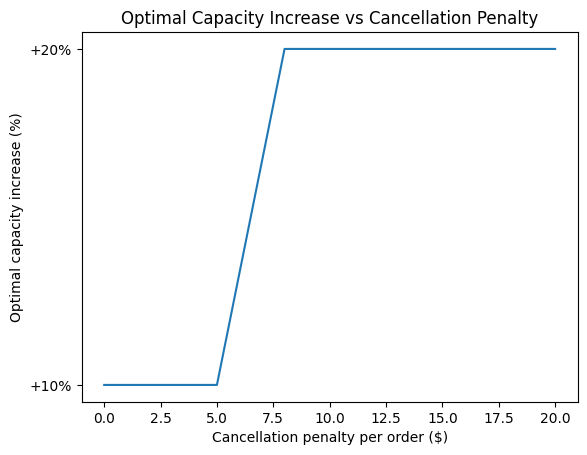

In [79]:
import matplotlib.pyplot as plt

penalties = [0, 2, 5, 8, 10, 15, 20]
best_policy = ["+10%", "+10%", "+10%", "+20%", "+20%", "+20%", "+20%"]

plt.figure()
plt.plot(penalties, [10 if p == "+10%" else 20 for p in best_policy])
plt.title("Optimal Capacity Increase vs Cancellation Penalty")
plt.xlabel("Cancellation penalty per order ($)")
plt.ylabel("Optimal capacity increase (%)")
plt.yticks([10, 20], ["+10%", "+20%"])
plt.show()

# compute exact tipping point (+10% vs +20%)

In [80]:
import pandas as pd

# ---- Assumptions (same as before) ----
cost_per_capacity_unit_per_hour = 1.50
hours = len(sim_input)

policies = [
    ("+10% capacity", 5500),
    ("+20% capacity", 6000)
]

# 1) Recompute canceled + revenue for each policy (source of truth)
rows = []
for name, cap in policies:
    out = simulate_marketplace(sim_input, demand_col="demand_forecast", supply_per_hour=cap)
    rows.append({
        "policy": name,
        "capacity_per_hour": cap,
        "canceled_orders": out["canceled"].sum(),
        "total_revenue": out["revenue"].sum(),
        "capacity_cost": cap * hours * cost_per_capacity_unit_per_hour
    })

dfp = pd.DataFrame(rows)
dfp["net_without_cancel_penalty"] = dfp["total_revenue"] - dfp["capacity_cost"]
dfp

,policy,capacity_per_hour,canceled_orders,total_revenue,capacity_cost,net_without_cancel_penalty
0,+10% capacity,5500,86693,19880289.6,2772000.0,17108289.6
1,+20% capacity,6000,40443,19787548.8,3024000.0,16763548.8


In [81]:
# 2) Exact break-even cancellation penalty p*
a = dfp.loc[dfp["policy"] == "+20% capacity"].iloc[0]
b = dfp.loc[dfp["policy"] == "+10% capacity"].iloc[0]

num = a["net_without_cancel_penalty"] - b["net_without_cancel_penalty"]
den = a["canceled_orders"] - b["canceled_orders"]

p_star = num / den  # this will be positive because den is negative and num is negative
p_star_abs = abs(p_star)

print("Break-even cancellation penalty p* ($ per cancel) where +10% and +20% are equal:")
print(p_star_abs)

Break-even cancellation penalty p* ($ per cancel) where +10% and +20% are equal:
7.453855135135151


“Derived an analytical break-even point: the optimal policy shifts from +10% to +20% capacity when the per-cancellation penalty exceeds $7.45
quantifying the tradeoff between capacity cost and reliability.”

# compute break-even cancellation penalty p* for every pair of policies.

In [83]:
import pandas as pd

cost_per_capacity_unit_per_hour = 1.50
hours = len(sim_input)

policies_all = [
    ("-10% capacity", 4500),
    ("Base", 5000),
    ("+10% capacity", 5500),
    ("+20% capacity", 6000)
]

rows = []
for name, cap in policies_all:
    out = simulate_marketplace(sim_input, demand_col="demand_forecast", supply_per_hour=cap)
    rows.append({
        "policy": name,
        "capacity_per_hour": cap,
        "canceled_orders": out["canceled"].sum(),
        "total_revenue": out["revenue"].sum(),
        "capacity_cost": cap * hours * cost_per_capacity_unit_per_hour
    })

dfp = pd.DataFrame(rows)
dfp["net_without_cancel_penalty"] = dfp["total_revenue"] - dfp["capacity_cost"]
dfp

,policy,capacity_per_hour,canceled_orders,total_revenue,capacity_cost,net_without_cancel_penalty
0,-10% capacity,4500,236749,19363735.8,2268000.0,17095735.8
1,Base,5000,156597,19578666.0,2520000.0,17058666.0
2,+10% capacity,5500,86693,19880289.6,2772000.0,17108289.6
3,+20% capacity,6000,40443,19787548.8,3024000.0,16763548.8


In [84]:
import itertools
import pandas as pd
import numpy as np

pairs = []
for p1, p2 in itertools.combinations(dfp["policy"].tolist(), 2):
    a = dfp.loc[dfp["policy"] == p1].iloc[0]
    b = dfp.loc[dfp["policy"] == p2].iloc[0]

    num = a["net_without_cancel_penalty"] - b["net_without_cancel_penalty"]
    den = a["canceled_orders"] - b["canceled_orders"]

    if abs(den) < 1e-9:
        p_star = np.nan
    else:
        p_star = num / den

    pairs.append({
        "policy_A": p1,
        "policy_B": p2,
        "break_even_p_star_$": float(abs(p_star)) if np.isfinite(p_star) else np.nan
    })

pairs_df = pd.DataFrame(pairs).sort_values("break_even_p_star_$")
pairs_df

,policy_A,policy_B,break_even_p_star_$
1,-10% capacity,+10% capacity,0.083661
0,-10% capacity,Base,0.462494
3,Base,+10% capacity,0.709882
2,-10% capacity,+20% capacity,1.692190
4,Base,+20% capacity,2.540741
5,+10% capacity,+20% capacity,7.453855


# Compute best policy across a range of penalties + plot

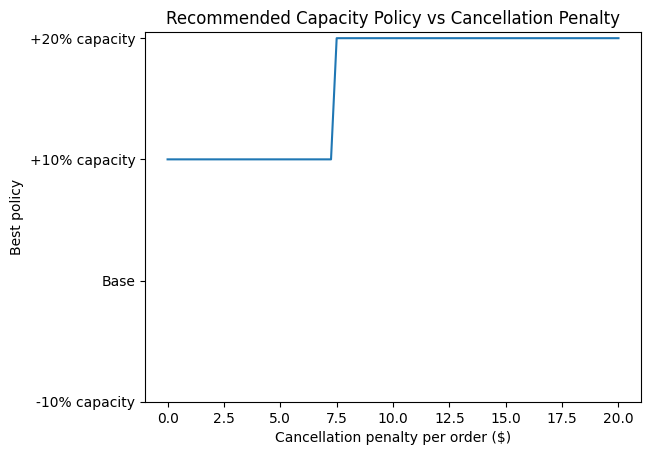

(   cancel_penalty    best_policy  best_profit
 0            0.00  +10% capacity  17108289.60
 1            0.25  +10% capacity  17086616.35
 2            0.50  +10% capacity  17064943.10
 3            0.75  +10% capacity  17043269.85
 4            1.00  +10% capacity  17021596.60,
     cancel_penalty    best_policy  best_profit
 76           19.00  +20% capacity  15995131.80
 77           19.25  +20% capacity  15985021.05
 78           19.50  +20% capacity  15974910.30
 79           19.75  +20% capacity  15964799.55
 80           20.00  +20% capacity  15954688.80)

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- SETTINGS ---
cost_per_capacity_unit_per_hour = 1.50
penalty_grid = np.linspace(0, 20, 81)   # 0 to 20 in steps of 0.25

policies_all = [
    ("-10% capacity", 4500),
    ("Base", 5000),
    ("+10% capacity", 5500),
    ("+20% capacity", 6000)
]

hours = len(sim_input)

# --- Precompute per-policy components that do NOT depend on penalty ---
base_rows = []
for name, cap in policies_all:
    out = simulate_marketplace(sim_input, demand_col="demand_forecast", supply_per_hour=cap)
    base_rows.append({
        "policy": name,
        "capacity_per_hour": cap,
        "canceled_orders": out["canceled"].sum(),
        "total_revenue": out["revenue"].sum(),
        "capacity_cost": cap * hours * cost_per_capacity_unit_per_hour
    })

base_df = pd.DataFrame(base_rows)
base_df["net_without_cancel_penalty"] = base_df["total_revenue"] - base_df["capacity_cost"]

# --- For each penalty, pick best policy ---
best_policies = []
best_profits = []

for p in penalty_grid:
    profits = base_df["net_without_cancel_penalty"] - p * base_df["canceled_orders"]
    best_idx = profits.idxmax()
    best_policies.append(base_df.loc[best_idx, "policy"])
    best_profits.append(profits.loc[best_idx])

result_df = pd.DataFrame({
    "cancel_penalty": penalty_grid,
    "best_policy": best_policies,
    "best_profit": best_profits
})

# --- Plot: Best policy vs penalty (step-like chart) ---
policy_to_code = {name: i for i, (name, _) in enumerate(policies_all)}
codes = [policy_to_code[p] for p in result_df["best_policy"]]

plt.figure()
plt.plot(result_df["cancel_penalty"], codes)
plt.title("Recommended Capacity Policy vs Cancellation Penalty")
plt.xlabel("Cancellation penalty per order ($)")
plt.ylabel("Best policy")
plt.yticks(list(policy_to_code.values()), list(policy_to_code.keys()))
plt.show()

result_df.head(), result_df.tail()

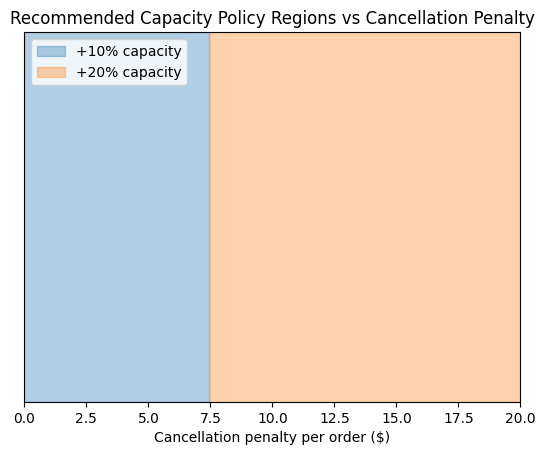

Policy regions:
+10% capacity: $0.00 to $7.45
+20% capacity: $7.50 to $20.00


In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- SETTINGS ----------
cost_per_capacity_unit_per_hour = 1.50
penalty_grid = np.linspace(0, 20, 401)  # 0 to 20 in steps of ~0.05

policies_all = [
    ("-10% capacity", 4500),
    ("Base", 5000),
    ("+10% capacity", 5500),
    ("+20% capacity", 6000)
]
# ----------------------------

hours = len(sim_input)

# 1) Precompute revenue, cancellations, and capacity cost for each policy (penalty-independent)
base_rows = []
for name, cap in policies_all:
    out = simulate_marketplace(sim_input, demand_col="demand_forecast", supply_per_hour=cap)
    base_rows.append({
        "policy": name,
        "capacity_per_hour": cap,
        "canceled_orders": out["canceled"].sum(),
        "total_revenue": out["revenue"].sum(),
        "capacity_cost": cap * hours * cost_per_capacity_unit_per_hour
    })

base_df = pd.DataFrame(base_rows)
base_df["net_without_cancel_penalty"] = base_df["total_revenue"] - base_df["capacity_cost"]

# 2) For each cancellation penalty, compute adjusted profit and select the best policy
best_policy = []
for p in penalty_grid:
    profits = base_df["net_without_cancel_penalty"] - p * base_df["canceled_orders"]
    best_idx = profits.idxmax()
    best_policy.append(base_df.loc[best_idx, "policy"])

result_df = pd.DataFrame({"cancel_penalty": penalty_grid, "best_policy": best_policy})

# 3) Convert best policy sequence into contiguous segments (ranges)
segments = []
start_i = 0
for i in range(1, len(result_df)):
    if result_df.loc[i, "best_policy"] != result_df.loc[i-1, "best_policy"]:
        segments.append((
            result_df.loc[start_i, "cancel_penalty"],
            result_df.loc[i-1, "cancel_penalty"],
            result_df.loc[i-1, "best_policy"]
        ))
        start_i = i

segments.append((
    result_df.loc[start_i, "cancel_penalty"],
    result_df.loc[len(result_df)-1, "cancel_penalty"],
    result_df.loc[len(result_df)-1, "best_policy"]
))

# 4) Colored region plot (explicit high-contrast colors)
color_map = {
    "-10% capacity": "#d62728",  # red
    "Base": "#2ca02c",           # green
    "+10% capacity": "#1f77b4",  # blue
    "+20% capacity": "#ff7f0e"   # orange
}

plt.figure()

for (x0, x1, pol) in segments:
    plt.axvspan(x0, x1, alpha=0.35, color=color_map.get(pol, "gray"), label=pol)

plt.title("Recommended Capacity Policy Regions vs Cancellation Penalty")
plt.xlabel("Cancellation penalty per order ($)")
plt.yticks([])

# Clean legend (unique labels)
handles, labels = plt.gca().get_legend_handles_labels()
unique = {}
for h, l in zip(handles, labels):
    if l not in unique:
        unique[l] = h
plt.legend(unique.values(), unique.keys(), loc="upper left")

plt.xlim(0, 20)
plt.show()

# Print the regions clearly
print("Policy regions:")
for x0, x1, pol in segments:
    print(f"{pol}: ${x0:.2f} to ${x1:.2f}")

Step 5 — Write the final outputs (2 things)
A) A one-page “Results” summary (what recruiters read)

Create a new markdown cell (or a separate notebook section) and write these 4 bullets (fill numbers from your run):

Forecasting performance

Seasonal Naive: WAPE 0.336

Random Forest: WAPE 0.063
(That’s a clean “baseline vs model” story.)

Marketplace impact (policy table)

Capacity 5000 → 6000 reduced cancels 9.7% → 2.5%

Queue delay proxy reduced ~70 min → ~30 min

Adjusted profit decision

With capacity cost = $1.50/unit/hour, optimal policy switches:

+10% when cancel penalty < $7.45

+20% when cancel penalty > $7.45

Business takeaway

“Investing in capacity is justified when cancellation cost is sufficiently high.”

# Step 6 — Make 3 “must-have” plots

## Actual vs Forecast (last 2 weeks)

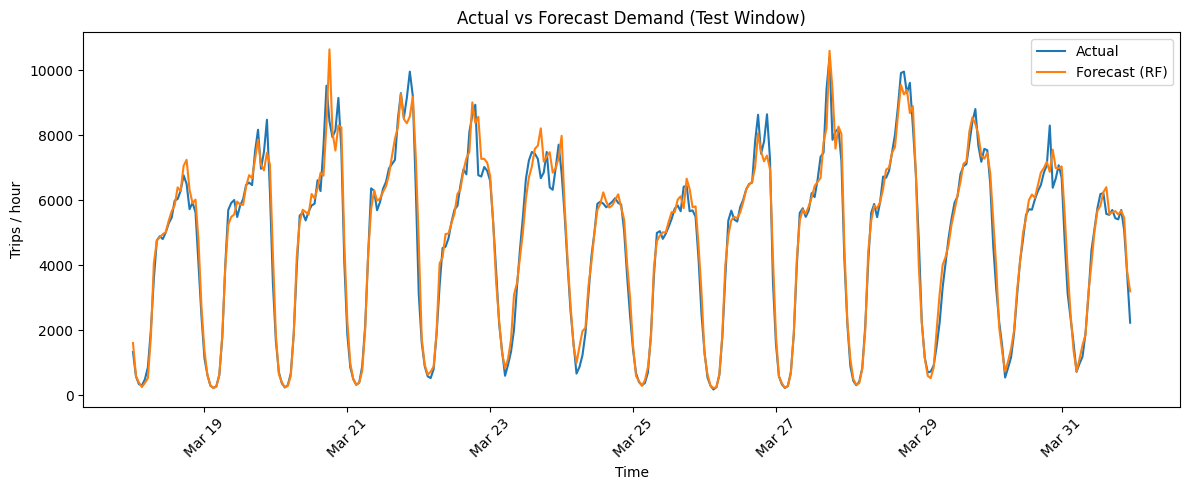

In [93]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12,5))
plt.plot(test_f["timestamp"], test_f["demand"].values, label="Actual")
plt.plot(test_f["timestamp"], rf_pred, label="Forecast (RF)")

plt.title("Actual vs Forecast Demand (Test Window)")
plt.xlabel("Time")
plt.ylabel("Trips / hour")
plt.legend()

# Show fewer ticks (every 2 days) + nice formatting
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))  # e.g., Mar 20
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Cancel rate vs capacity (from your policy table)

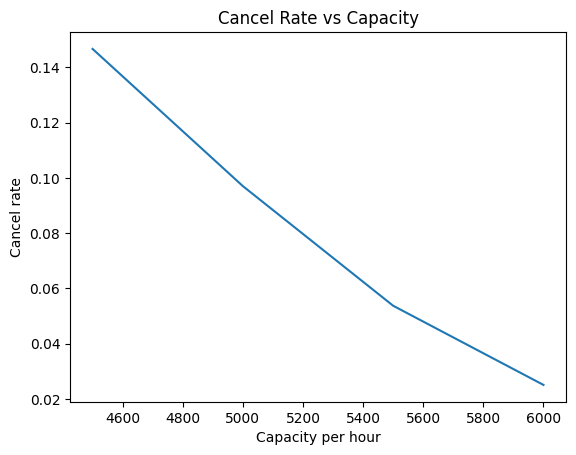

In [90]:
pt = policy_table.sort_values("capacity_per_hour")

plt.figure()
plt.plot(pt["capacity_per_hour"], pt["cancel_rate"])
plt.title("Cancel Rate vs Capacity")
plt.xlabel("Capacity per hour")
plt.ylabel("Cancel rate")
plt.show()

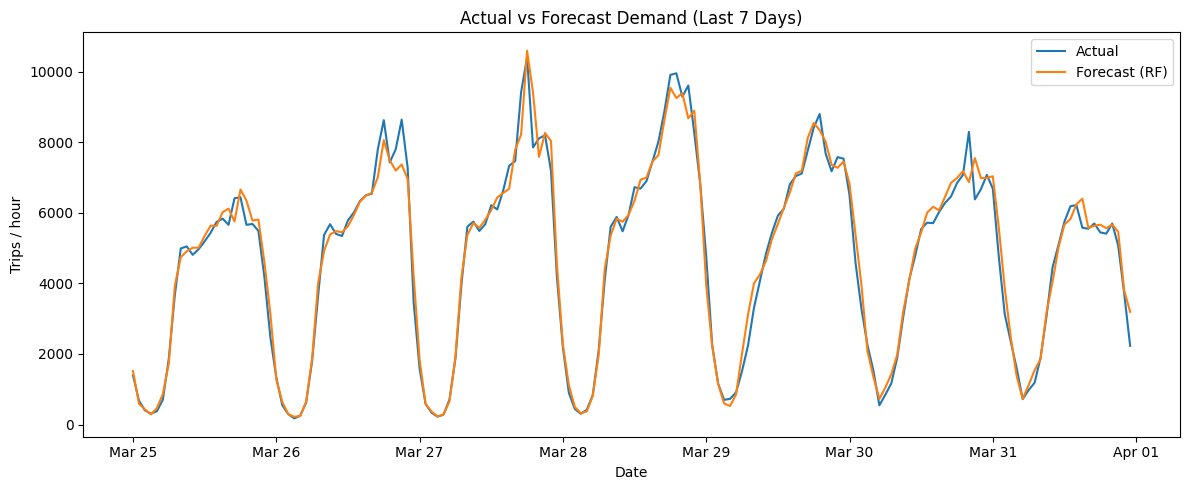

In [95]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

n = 24 * 7

plt.figure(figsize=(12,5))
plt.plot(test_f["timestamp"].iloc[-n:], test_f["demand"].values[-n:], label="Actual")
plt.plot(test_f["timestamp"].iloc[-n:], rf_pred[-n:], label="Forecast (RF)")

plt.title("Actual vs Forecast Demand (Last 7 Days)")
plt.xlabel("Date")
plt.ylabel("Trips / hour")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

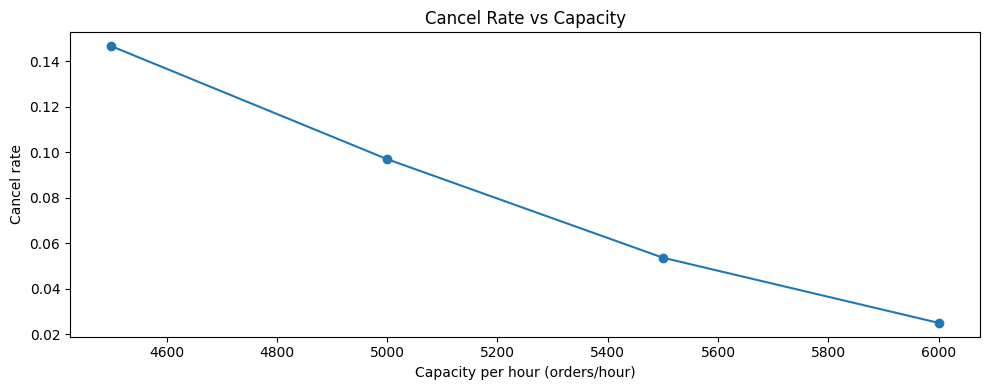

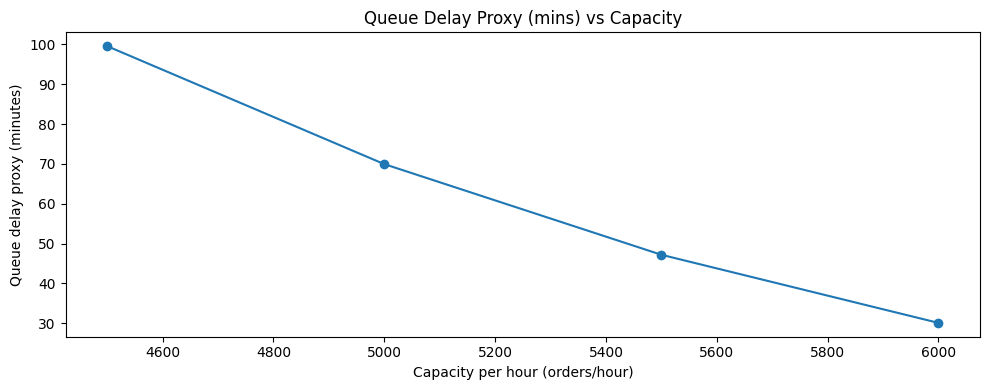

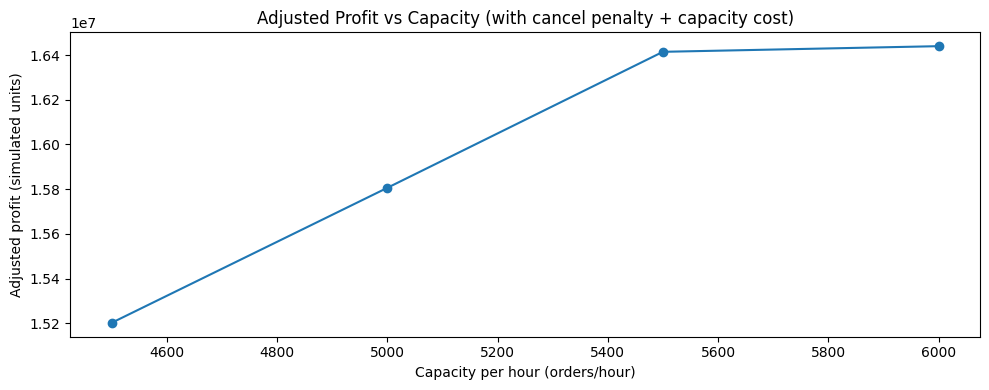

In [96]:
import matplotlib.pyplot as plt

# Make sure policy_table exists from your earlier policy comparison
pt = policy_table.sort_values("capacity_per_hour")

# --- Plot 1: Cancel rate vs capacity ---
plt.figure(figsize=(10,4))
plt.plot(pt["capacity_per_hour"], pt["cancel_rate"], marker="o")
plt.title("Cancel Rate vs Capacity")
plt.xlabel("Capacity per hour (orders/hour)")
plt.ylabel("Cancel rate")
plt.tight_layout()
plt.show()

# --- Plot 2: Queue delay proxy vs capacity ---
plt.figure(figsize=(10,4))
plt.plot(pt["capacity_per_hour"], pt["avg_queue_delay_mins"], marker="o")
plt.title("Queue Delay Proxy (mins) vs Capacity")
plt.xlabel("Capacity per hour (orders/hour)")
plt.ylabel("Queue delay proxy (minutes)")
plt.tight_layout()
plt.show()

# --- Plot 3: Adjusted profit vs capacity (optional) ---
# This requires adj_table from your "adjusted profit" cell.
# If you haven't computed adj_table, this will just skip.
try:
    ap = adj_table.sort_values("capacity_per_hour")
    plt.figure(figsize=(10,4))
    plt.plot(ap["capacity_per_hour"], ap["profit_adj"], marker="o")
    plt.title("Adjusted Profit vs Capacity (with cancel penalty + capacity cost)")
    plt.xlabel("Capacity per hour (orders/hour)")
    plt.ylabel("Adjusted profit (simulated units)")
    plt.tight_layout()
    plt.show()
except NameError:
    print("adj_table not found (skip profit plot). Run the adjusted profit cell first if you want this plot.")

Random Forest demand forecasting reduced error from baseline WAPE 0.336 → 0.063 on the 2-week test window.

Simulator-based policy evaluation showed increasing capacity from 5000 → 6000 orders/hour reduced cancellation rate from 9.7% → 2.5% and reduced queue delay proxy from ~70 min → ~30 min.

Under capacity cost $1.50/unit/hour and cancellation penalty $8/cancel, adjusted profit increased from ~15.8M (Base) to ~16.44M (+20%) with diminishing returns beyond +10%.

Break-even analysis showed the optimal policy switches from +10% to +20% when cancellation penalty exceeds ~$7.45.